# 1: Byte-Pair-Encoding

### Task 1

Prepare the data and normalization.

**Reuse.** `byte_pair_encoder.py` is preserved byte for byte. The shared `bpe.py` calls its `get_vocabulary`, `add_to_counter`, and `subtract_from_counter` helpers unchanged. Its corpus-wide encoder needed changes: it does not store reusable merge rules, uses concatenated strings rather than pair keys, can merge across words, and does not implement all requested normalization, persistence, or held-out encoding. The replacement training loop keeps the original idea of updating counts locally, but applies it to weighted word types with tuple pair keys and alphabetical tie-breaking. It uses only the Python standard library.

**Data.** Keep the first 99% of Shakespeare's lines for training and the last 1% for testing, without shuffling. Join each part with `\n`; the reported character count includes these separators. The two comparison texts are the assignment's suggested *Pride and Prejudice* and the CPython 3.13.0 `test_typing.py` source file. Use the complete downloaded files, including their headers/comments, and never train on them. SHA-256 checks identify the exact files; both must exceed 200,000 bytes.

**Normalization and boundaries.** `raw` changes nothing; `lower` lowercases; `clean` applies lower → NFKC → digit replacement → collapse horizontal whitespace to one space; `split` also surrounds every Unicode punctuation character with spaces. Newlines are retained. The main marker is the suffix `</w>`; the alternative is the prefix `▁`. Whitespace is encoded separately, so merges never cross a word boundary and raw spacing is reversible. At `k=0`, emit characters only, without synthetic markers: this is the pure character baseline.

Assignment 1 uses its own 99/1 data split and `models/assignment1/` outputs. Assignment 3 refits the same tokenizer implementation on its own 80/10/10 split; reusing the 99%-trained merges there would leak held-out data.

In [1]:
from pathlib import Path
import hashlib
import inspect
import json
import platform
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Code
from bpe import BPETokenizer, WordTokenizer, normalize, merge_pair
from byte_pair_encoder import BytePairEncoder
from assignment1_utils import load_corpora, measure, stability, roundtrip_accuracy

A1_START = time.perf_counter()
A1_SEED = 42
random.seed(A1_SEED)
np.random.seed(A1_SEED)
a1_model_dir = Path('models/assignment1')
a1_result_dir = Path('results/assignment1')
a1_model_dir.mkdir(parents=True, exist_ok=True)
a1_result_dir.mkdir(parents=True, exist_ok=True)
a1_texts, a1_sources = load_corpora()
a1_lines = a1_texts['Shakespeare'].splitlines()
a1_split = int(0.99 * len(a1_lines))
a1_train_lines, a1_test_lines = a1_lines[:a1_split], a1_lines[a1_split:]
a1_train_text, a1_test_text = '\n'.join(a1_train_lines), '\n'.join(a1_test_lines)
a1_midpoint = len(a1_train_lines) // 2
a1_half_texts = ['\n'.join(a1_train_lines[:a1_midpoint]), '\n'.join(a1_train_lines[a1_midpoint:])]
a1_domains = {'Shakespeare test': a1_test_text,
              'English prose': a1_texts['English prose'],
              'Python source': a1_texts['Python source']}
print(f'Seed: {A1_SEED}; deterministic line split; {platform.platform()}')
display(pd.DataFrame([
    dict(split=name, lines=len(text.splitlines()), words=len(text.split()), characters=len(text))
    for name, text in [('Train (99%)', a1_train_text), ('Test (1%)', a1_test_text)]
]))
display(pd.DataFrame(a1_sources)[['corpus', 'bytes', 'sha256']])
for source in a1_sources:
    display(Markdown(f"[{source['corpus']} source]({source['url']})"))
assert len(a1_train_lines) == 39600 and len(a1_test_lines) == 400
(a1_result_dir / 'data_sources.json').write_text(json.dumps(a1_sources, indent=2))

Seed: 42; deterministic line split; macOS-15.7.1-arm64-arm-64bit


,split,lines,words,characters
0,Train (99%),39599,201253,1107366
1,Test (1%),400,1398,8022


,corpus,bytes,sha256
0,Shakespeare,1115390,434c0554a8c4c53dc17e56a0abb0f30b88f83cbceb0289...
1,English prose,772386,3f6bb9d6f78e0293b56acd4714dd68cb7d6d1d29340203...
2,Python source,376291,750a931fa976f8ca7a113f946eddda380a2d68b64f94bc...


[Shakespeare source](https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt)

[English prose source](https://www.gutenberg.org/ebooks/1342.txt.utf-8)

[Python source source](https://raw.githubusercontent.com/python/cpython/v3.13.0/Lib/test/test_typing.py)

688

In [2]:
display(Code(inspect.getsource(normalize), language='python'))
a1_example = '  HELLO,  Ｗorld! 2026\tNow.  '
display(pd.DataFrame([
    {'strategy': strategy, 'input (repr)': repr(a1_example),
     'output (repr)': repr(normalize(a1_example, strategy))}
    for strategy in ['raw', 'lower', 'clean', 'split']
]))
assert normalize(a1_example, 'raw') == a1_example
assert normalize('A １２3', 'clean') == 'a 000'
assert normalize('a,b!', 'split') == 'a , b ! '
print('Raw whitespace and normalization examples checked.')

def normalize(text, strategy="clean"):
    if strategy == "raw":
        return text
    text = text.lower()
    if strategy == "lower":
        return text
    if strategy not in {"clean", "split"}:
        raise ValueError(strategy)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"\d", "0", text)
    text = re.sub(r"[^\S\n]+", " ", text)
    if strategy == "split":
        text = "".join(f" {c} " if unicodedata.category(c).startswith("P") else c
                       for c in text)
        text = re.sub(r"[^\S\n]+", " ", text)
    return text

,strategy,input (repr),output (repr)
0,raw,"' HELLO, Ｗorld! 2026\tNow. '","' HELLO, Ｗorld! 2026\tNow. '"
1,lower,"' HELLO, Ｗorld! 2026\tNow. '","' hello, ｗorld! 2026\tnow. '"
2,clean,"' HELLO, Ｗorld! 2026\tNow. '","' hello, world! 0000 now. '"
3,split,"' HELLO, Ｗorld! 2026\tNow. '","' hello , world ! 0000 now . '"


Raw whitespace and normalization examples checked.


### Task 2

Train deterministic merges efficiently.

Count each adjacent **pair of symbols** within each word type, weighted by the frequency of that word. A heap chooses the largest count; the pair tuple breaks ties alphabetically. After merging, update only word types containing that pair and the adjacent-pair counts affected by those replacements. Stale heap entries are discarded. Replace overlapping matches left to right without overlapping replacements. Keep the learned pair list in order and retain all base symbols in the vocabulary.

The original `O(n+k)` comment is not a bound for this implementation: training also depends on affected word lengths, occurrences, and heap updates. We report actual elapsed training time for every configuration and explicitly check the 8,000-merge run against the ten-minute limit.

In [3]:
print('Original vocabulary/count helpers are called without modification.')
display(Code(inspect.getsource(BPETokenizer.train), language='python'))
display(Code(inspect.getsource(merge_pair), language='python'))

a1_registry = {}
def a1_fit(k, strategy='clean', marker='end'):
    key = (k, strategy, marker)
    if key not in a1_registry:
        kwargs = dict(num_merges=k, strategy=strategy)
        if marker == 'start':
            kwargs['start_of_word'] = '▁'
        tokenizer = BPETokenizer(**kwargs)
        started = time.perf_counter()
        tokenizer.train(a1_train_text)
        elapsed = time.perf_counter() - started
        path = a1_model_dir / f'bpe_{strategy}_{marker}_{k}.json'
        tokenizer.save(path)
        a1_registry[key] = dict(tok=tokenizer, seconds=elapsed, path=path, halves=None)
        print(f'{strategy:5s}, {marker:5s}, k={k:4d}: {elapsed:.3f} s; '
              f'{len(tokenizer.merges)} merges; V={len(tokenizer.vocab)}', flush=True)
        if k == 8000:
            assert elapsed < 600, '8,000 merges exceeded the ten-minute limit.'
    return a1_registry[key]

# The first merge has several equally frequent candidates; ('a', 'b') wins alphabetically.
a1_tie = BPETokenizer(1, strategy='raw').train('ab ac')
assert a1_tie.merges == [('a', 'b')]
assert merge_pair(tuple('aaaaa'), ('a', 'a')) == ('aa', 'aa', 'a')
a1_toy = BPETokenizer(20, strategy='raw').train('low lower low  lowest\nlow')
a1_toy_copy = BPETokenizer(20, strategy='raw').train('low lower low  lowest\nlow')
assert a1_toy.merges == a1_toy_copy.merges and a1_toy.vocab == a1_toy_copy.vocab
assert not any(any(character.isspace() for character in symbol)
               for pair in a1_toy.merges for symbol in pair)
print('Tie, overlapping-pair, determinism, and word-boundary checks passed.')
a1_main = a1_fit(1000)
print('First ten learned pairs:', a1_main['tok'].merges[:10])

Original vocabulary/count helpers are called without modification.


def train(self, train_text):
        text = normalize(train_text, self.strategy)
        if self.marker in text:
            raise ValueError("The reserved boundary marker occurs in training text")
        frequencies = Counter(text.split())
        words = {w: self._with_boundary(tuple(w)) for w in sorted(frequencies)}
        # Reuse the original deterministic vocabulary helper unchanged.
        alphabet = BytePairEncoder.get_vocabulary(text)
        symbols = ["<bos>", "<eos>", "<unk>", self.marker] + alphabet
        self.vocab = {s: i for i, s in enumerate(dict.fromkeys(symbols))}
        self.merges = []
        counts, members = {}, defaultdict(set)
        for word, pieces in words.items():
            for pair, count in Counter(zip(pieces, pieces[1:])).items():
                BytePairEncoder.add_to_counter(counts, pair, count * frequencies[word])
                members[pair].add(word)
        heap = [(-count, pair) for pair, count in counts.items() if count > 0]
        heapq.heapify(heap)
        for _ in range(self.num_merges):
            while heap:
                negative_count, pair = heapq.heappop(heap)
                if counts.get(pair, 0) == -negative_count:
                    break
            else:
                break
            changed_pairs = set()
            # Sorted iteration and tuple tie-breaking make training deterministic.
            for word in sorted(members[pair].copy()):
                before = Counter(zip(words[word], words[word][1:]))
                words[word] = merge_pair(words[word], pair)
                after = Counter(zip(words[word], words[word][1:]))
                for adjacent in before.keys() | after.keys():
                    difference = (after[adjacent] - before[adjacent]) * frequencies[word]
                    if difference > 0:
                        BytePairEncoder.add_to_counter(counts, adjacent, difference)
                    elif difference < 0:
                        BytePairEncoder.subtract_from_counter(counts, adjacent, -difference)
                    if after[adjacent]:
                        members[adjacent].add(word)
                    else:
                        members[adjacent].discard(word)
                    if difference:
                        changed_pairs.add(adjacent)
            self.merges.append(pair)
            joined = "".join(pair)
            if joined not in self.vocab:
                self.vocab[joined] = len(self.vocab)
            for adjacent in sorted(changed_pairs):
                if counts[adjacent] > 0:
                    heapq.heappush(heap, (-counts[adjacent], adjacent))
        self._prepare()
        return self

def merge_pair(symbols, pair):
    result, i = [], 0
    while i < len(symbols):
        if i + 1 < len(symbols) and (symbols[i], symbols[i + 1]) == pair:
            result.append(symbols[i] + symbols[i + 1])
            i += 2
        else:
            result.append(symbols[i])
            i += 1
    return tuple(result)

Tie, overlapping-pair, determinism, and word-boundary checks passed.


clean, end  , k=1000: 0.555 s; 1000 merges; V=1043


First ten learned pairs: [('e', '</w>'), ('t', 'h'), (',', '</w>'), ('t', '</w>'), ('s', '</w>'), ('d', '</w>'), ('o', 'u'), ('a', 'n'), ('e', 'r'), ('i', 'n')]


### Task 3

Encode, decode, save, and load.

Encoding starts from each word's characters and applies learned merges in rank order. Unknown characters map individually to `<unk>`; decoding cannot recover their identity. Spaces and newlines remain separate tokens, and decoding removes only the synthetic word marker. The raw Shakespeare test set contains no unseen characters, so every raw test line must round-trip exactly. For the other strategies compare with the normalized line, since case, digits, or spacing may have been deliberately changed.

JSON files store the strategy, marker choice, merge list, and token-to-ID mapping. Loading must reproduce the same IDs and decoded strings. The constructor's default strategy is `clean`, preserving the existing Assignment 3 behavior.

In [4]:
display(Code(inspect.getsource(BPETokenizer._encode_word), language='python'))
display(Code(inspect.getsource(BPETokenizer.encode), language='python'))
display(Code(inspect.getsource(BPETokenizer.decode), language='python'))
a1_roundtrip_rows = []
for strategy in ['raw', 'lower', 'clean', 'split']:
    record = a1_fit(2000, strategy)
    tokenizer = record['tok']
    restored = BPETokenizer.load(record['path'])
    correct = sum(tokenizer.decode(tokenizer.encode(line)) == normalize(line, strategy)
                  for line in a1_test_lines)
    unknown = sum(tokenizer.encode(line).count(tokenizer.unk_id) for line in a1_test_lines)
    assert restored.merges == tokenizer.merges and restored.vocab == tokenizer.vocab
    assert all(restored.encode(line) == tokenizer.encode(line) for line in a1_test_lines)
    assert correct == len(a1_test_lines)
    a1_roundtrip_rows.append(dict(strategy=strategy, correct_lines=correct,
        test_lines=len(a1_test_lines), accuracy=correct / len(a1_test_lines), unknown_tokens=unknown))
display(pd.DataFrame(a1_roundtrip_rows))

a1_raw = a1_registry[(2000, 'raw', 'end')]['tok']
a1_line = next(line for line in a1_test_lines if line.strip())
a1_ids = a1_raw.encode(a1_line)
print('Original:', repr(a1_line))
print('Token IDs:', a1_ids)
print('Symbols:', [a1_raw._id_to_token[i] for i in a1_ids])
print('Decoded:', repr(a1_raw.decode(a1_ids)))
a1_unseen_ids = a1_raw.encode('☃')
assert a1_unseen_ids.count(a1_raw.unk_id) == 1
print('Unseen-character example: ☃ ->', [a1_raw._id_to_token[i] for i in a1_unseen_ids])
print('Raw test round-trip accuracy: 1.000; all four strategies checked against their correct targets.')

def _encode_word(self, word):
        if word not in self._cache:
            pieces = tuple(c if c in self._characters else "<unk>" for c in word)
            # k=0 is the pure character baseline: emit no synthetic marker.
            if self.num_merges != 0:
                pieces = self._with_boundary(pieces)
            while len(pieces) > 1:
                candidates = [p for p in zip(pieces, pieces[1:]) if p in self._ranks]
                if not candidates:
                    break
                pair = min(candidates, key=self._ranks.get)
                pieces = merge_pair(pieces, pair)
            self._cache[word] = [self.vocab[p] for p in pieces]
        return self._cache[word]

def encode(self, text):
        ids = []
        for chunk in re.findall(r"\s+|\S+", normalize(text, self.strategy)):
            if chunk.isspace():
                ids.extend(self.vocab.get(c, self.unk_id) for c in chunk)
            else:
                ids.extend(self._encode_word(chunk))
        return ids

def decode(self, ids):
        return "".join(self._without_boundary(self._id_to_token[int(i)]) for i in ids
                       if int(i) not in (self.bos_id, self.eos_id))

raw  , end  , k=2000: 0.602 s; 2000 merges; V=2069


lower, end  , k=2000: 0.594 s; 2000 merges; V=2043


clean, end  , k=2000: 0.615 s; 2000 merges; V=2043


split, end  , k=2000: 0.416 s; 2000 merges; V=2043


,strategy,correct_lines,test_lines,accuracy,unknown_tokens
0,raw,400,400,1.0,0
1,lower,400,400,1.0,0
2,clean,400,400,1.0,0
3,split,400,400,1.0,0


Original: 'ANTONIO:'
Token IDs: [273, 36, 393, 208]
Symbols: ['AN', 'T', 'ON', 'IO:</w>']
Decoded: 'ANTONIO:'
Unseen-character example: ☃ -> ['<unk>', '</w>']
Raw test round-trip accuracy: 1.000; all four strategies checked against their correct targets.


### Task 4

Run the three experiments.

All tokenizers learn only from the Shakespeare training split. The word baseline keeps the 8,000 most frequent word types (frequency ties are alphabetical) and preserves whitespace like BPE. Its unknown-word IDs are distinct from BPE's unknown-character events, so UNK rates describe different token units.

The tables report all three size/coverage measures, round-trip accuracy, and our additional **stability** measure. For stability, fit the same configuration to the first and second halves of the training lines, then compare their internal cut positions on distinct words encodable by both. The stability denominator and coverage are retained in the saved tables; Task 5 gives the formula and limitation. These auxiliary models never train on the test or comparison corpora.

A logarithmic axis cannot contain zero. The plots therefore place positive merge counts on the log axis and show `k=0` character results as horizontal reference lines; the 8,000-word baseline is another reference line, not a BPE merge count.

In [5]:
def a1_half_models(k, strategy='clean', marker='end'):
    record = a1_fit(k, strategy, marker)
    if record['halves'] is None:
        kwargs = dict(num_merges=k, strategy=strategy)
        if marker == 'start':
            kwargs['start_of_word'] = '▁'
        record['halves'] = tuple(BPETokenizer(**kwargs).train(text) for text in a1_half_texts)
    return record['halves']

A1_KS = [0, 100, 250, 500, 1000, 2000, 4000, 8000]
a1_k_rows = []
for k in A1_KS:
    record = a1_fit(k)
    half_models = a1_half_models(k)
    for split, text in [('train', a1_train_text), ('test', a1_test_text)]:
        a1_k_rows.append(dict(model='BPE', k=k, split=split,
            training_seconds=record['seconds'], **measure(record['tok'], text, half_models)))

a1_started = time.perf_counter()
a1_word = WordTokenizer(max_words=8000).train(a1_train_text)
a1_word_seconds = time.perf_counter() - a1_started
a1_word_halves = tuple(WordTokenizer(max_words=8000).train(text) for text in a1_half_texts)
for split, text in [('train', a1_train_text), ('test', a1_test_text)]:
    a1_k_rows.append(dict(model='Word (8000)', k=None, split=split,
        training_seconds=a1_word_seconds, **measure(a1_word, text, a1_word_halves)))
a1_k_table = pd.DataFrame(a1_k_rows)
a1_metric_columns = ['compression ratio', 'tokens per word', 'UNK rate',
                     'round-trip accuracy', 'stability', 'stability coverage']
display(a1_k_table[['model', 'k', 'split', 'training_seconds'] + a1_metric_columns].round(5))
display(a1_k_table[['model', 'k', 'split', 'characters', 'words', 'tokens', 'unknown tokens',
                      'stability eligible types']])
assert (a1_k_table.query("model == 'BPE' and k == 0")['compression ratio'] == 1).all()
assert (a1_k_table.query("model == 'BPE'")['round-trip accuracy'] == 1).all()
a1_k_table.to_csv(a1_result_dir / 'vary_k.csv', index=False)

clean, end  , k=   0: 0.088 s; 0 merges; V=43


clean, end  , k= 100: 0.443 s; 100 merges; V=143


clean, end  , k= 250: 0.610 s; 250 merges; V=293


clean, end  , k= 500: 0.627 s; 500 merges; V=543


clean, end  , k=4000: 0.877 s; 4000 merges; V=4043


clean, end  , k=8000: 0.960 s; 8000 merges; V=8043


,model,k,split,training_seconds,compression ratio,tokens per word,UNK rate,round-trip accuracy,stability,stability coverage
0,BPE,0.0,train,0.08764,1.00000,5.50229,0.00000,1.00000,1.00000,0.99991
1,BPE,0.0,test,0.08764,1.00000,5.73820,0.00000,1.00000,1.00000,1.00000
2,BPE,100.0,train,0.44322,1.32868,4.14118,0.00000,1.00000,0.82119,0.99991
3,BPE,100.0,test,0.44322,1.30993,4.38054,0.00000,1.00000,0.85865,1.00000
4,BPE,250.0,train,0.60989,1.56648,3.51251,0.00000,1.00000,0.65817,0.99991
5,BPE,250.0,test,0.60989,1.52626,3.75966,0.00000,1.00000,0.71429,1.00000
6,BPE,500.0,train,0.62686,1.75967,3.12688,0.00000,1.00000,0.65570,0.99991
7,BPE,500.0,test,0.62686,1.68636,3.40272,0.00000,1.00000,0.72030,1.00000
8,BPE,1000.0,train,0.55466,1.95938,2.80818,0.00000,1.00000,0.63860,0.99991
9,BPE,1000.0,test,0.55466,1.83234,3.13162,0.00000,1.00000,0.73985,1.00000


,model,k,split,characters,words,tokens,unknown tokens,stability eligible types
0,BPE,0.0,train,1107352,201253,1107352,0,23506
1,BPE,0.0,test,8022,1398,8022,0,665
2,BPE,100.0,train,1107352,201253,833424,0,23506
3,BPE,100.0,test,8022,1398,6124,0,665
4,BPE,250.0,train,1107352,201253,706904,0,23506
5,BPE,250.0,test,8022,1398,5256,0,665
6,BPE,500.0,train,1107352,201253,629294,0,23506
7,BPE,500.0,test,8022,1398,4757,0,665
8,BPE,1000.0,train,1107352,201253,565155,0,23506
9,BPE,1000.0,test,8022,1398,4378,0,665


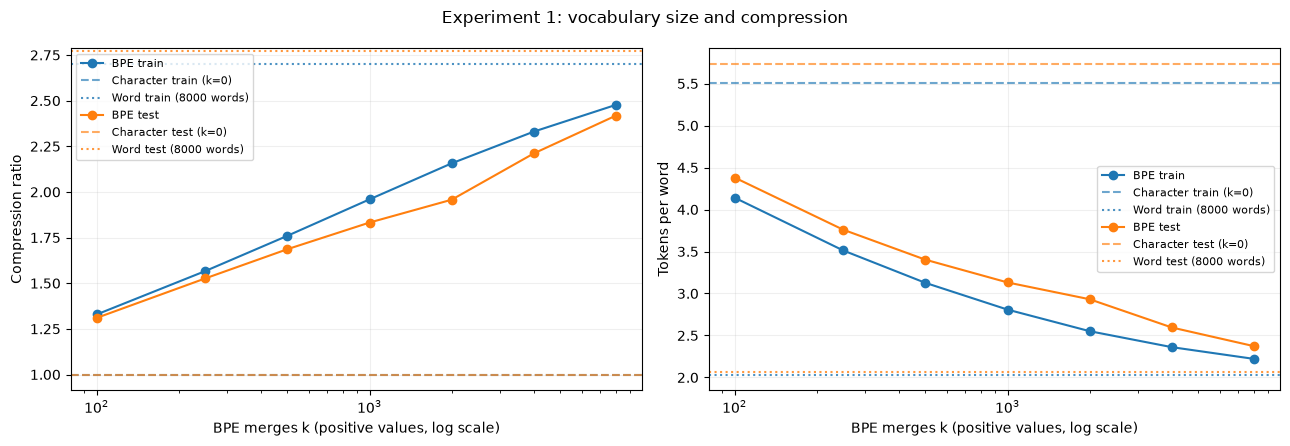

On the test split, increasing k from 0 to 8,000 changes compression from 1.000 to 2.418 characters per token and tokens per word from 5.738 to 2.373. Larger vocabularies store longer units, but these size measures alone do not establish linguistic quality.

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ['compression ratio', 'tokens per word']):
    for split, color in [('train', 'tab:blue'), ('test', 'tab:orange')]:
        rows = a1_k_table.query("model == 'BPE' and k > 0 and split == @split")
        ax.plot(rows['k'], rows[metric], marker='o', color=color, label=f'BPE {split}')
        char_value = a1_k_table.query("model == 'BPE' and k == 0 and split == @split")[metric].iloc[0]
        word_value = a1_k_table.query("model == 'Word (8000)' and split == @split")[metric].iloc[0]
        ax.axhline(char_value, color=color, linestyle='--', alpha=.65, label=f'Character {split} (k=0)')
        ax.axhline(word_value, color=color, linestyle=':', alpha=.8, label=f'Word {split} (8000 words)')
    ax.set_xscale('log')
    ax.set(xlabel='BPE merges k (positive values, log scale)', ylabel=metric.capitalize())
    ax.grid(alpha=.2)
    ax.legend(fontsize=8)
fig.suptitle('Experiment 1: vocabulary size and compression')
fig.tight_layout()
plt.show()
a1_low = a1_k_table.query("model == 'BPE' and k == 0 and split == 'test'").iloc[0]
a1_high = a1_k_table.query("model == 'BPE' and k == 8000 and split == 'test'").iloc[0]
display(Markdown(f"On the test split, increasing k from 0 to 8,000 changes compression from {a1_low['compression ratio']:.3f} to {a1_high['compression ratio']:.3f} characters per token and tokens per word from {a1_low['tokens per word']:.3f} to {a1_high['tokens per word']:.3f}. Larger vocabularies store longer units, but these size measures alone do not establish linguistic quality."))

In [7]:
# Experiment 2: change only normalization or marker, at k=2000.
a1_normalization_rows = []
for strategy, marker in [('raw', 'end'), ('lower', 'end'), ('clean', 'end'),
                         ('split', 'end'), ('clean', 'start')]:
    record = a1_fit(2000, strategy, marker)
    half_models = a1_half_models(2000, strategy, marker)
    for split, text in [('train', a1_train_text), ('test', a1_test_text)]:
        a1_normalization_rows.append(dict(strategy=strategy, marker=marker, split=split,
            training_seconds=record['seconds'], **measure(record['tok'], text, half_models)))
a1_normalization_table = pd.DataFrame(a1_normalization_rows)
display(a1_normalization_table[['strategy', 'marker', 'split', 'training_seconds'] + a1_metric_columns].round(5))
assert (a1_normalization_table['round-trip accuracy'] == 1).all()
a1_normalization_table.to_csv(a1_result_dir / 'normalization_and_markers.csv', index=False)
a1_marker_rows = a1_normalization_table.query("strategy == 'clean' and split == 'test'")
a1_end_ratio = a1_marker_rows.query("marker == 'end'")['compression ratio'].iloc[0]
a1_start_ratio = a1_marker_rows.query("marker == 'start'")['compression ratio'].iloc[0]
display(Markdown(f"At k=2,000 on the clean test split, the suffix marker gives {a1_end_ratio:.3f} characters per token and the prefix marker gives {a1_start_ratio:.3f}. They expose different boundary-adjacent pairs to the same merge learner; every normalization/marker configuration still reconstructs its own normalized test input exactly."))

clean, start, k=2000: 0.635 s; 2000 merges; V=2043


,strategy,marker,split,training_seconds,compression ratio,tokens per word,UNK rate,round-trip accuracy,stability,stability coverage
0,raw,end,train,0.60210,2.06665,2.66245,0.0,1.0,0.65218,0.99992
1,raw,end,test,0.60210,1.87737,3.05651,0.0,1.0,0.76039,1.00000
2,lower,end,train,0.59427,2.15678,2.55119,0.0,1.0,0.60355,0.99991
3,lower,end,test,0.59427,1.95754,2.93133,0.0,1.0,0.73835,1.00000
4,clean,end,train,0.61473,2.15682,2.55112,0.0,1.0,0.60355,0.99991
5,clean,end,test,0.61473,1.95754,2.93133,0.0,1.0,0.73835,1.00000
6,split,end,train,0.41627,1.94207,2.35375,0.0,1.0,0.62478,0.99982
7,split,end,test,0.41627,1.79260,2.57715,0.0,1.0,0.78662,1.00000
8,clean,start,train,0.63520,2.18241,2.52119,0.0,1.0,0.54578,0.99991
9,clean,start,test,0.63520,2.00751,2.85837,0.0,1.0,0.73835,1.00000


At k=2,000 on the clean test split, the suffix marker gives 1.958 characters per token and the prefix marker gives 2.008. They expose different boundary-adjacent pairs to the same merge learner; every normalization/marker configuration still reconstructs its own normalized test input exactly.

,model,k,corpus,compression ratio,tokens per word,UNK rate,round-trip accuracy,stability,stability coverage
0,BPE,0.0,Shakespeare test,1.00000,5.73820,0.00000,1.00000,1.00000,1.00000
1,BPE,0.0,English prose,1.00000,5.68227,0.00856,0.73999,1.00000,0.85458
2,BPE,0.0,Python source,1.00000,12.18493,0.12018,0.26086,1.00000,0.18364
3,BPE,100.0,Shakespeare test,1.30993,4.38054,0.00000,1.00000,0.85865,1.00000
4,BPE,100.0,English prose,1.33049,4.27081,0.01138,0.73999,0.79188,0.85458
5,BPE,100.0,Python source,1.14112,10.67806,0.13713,0.26086,0.83394,0.18364
6,BPE,250.0,Shakespeare test,1.52626,3.75966,0.00000,1.00000,0.71429,1.00000
7,BPE,250.0,English prose,1.54382,3.68066,0.01321,0.73999,0.65415,0.85458
8,BPE,250.0,Python source,1.26441,9.63686,0.15195,0.26086,0.65199,0.18364
9,BPE,500.0,Shakespeare test,1.68636,3.40272,0.00000,1.00000,0.72030,1.00000


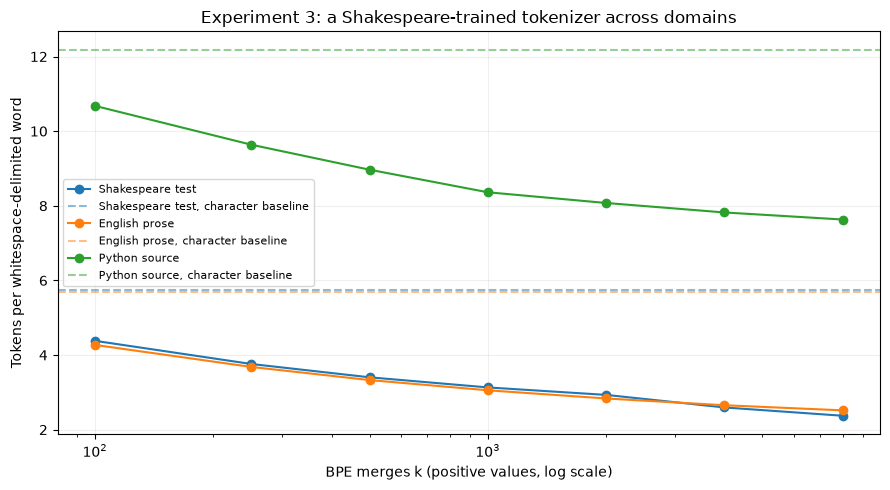

At k=8,000, **Python source** requires the most tokens per word (7.632). Word lengths, source-code syntax, unseen characters, and how well Shakespeare's learned pieces transfer all affect this measure; higher compression does not imply better meaning preservation.

In [8]:
# Experiment 3: reuse the fitted models; no fitting on either comparison corpus.
a1_domain_rows = []
for k in A1_KS:
    record = a1_registry[(k, 'clean', 'end')]
    for name, text in a1_domains.items():
        a1_domain_rows.append(dict(model='BPE', k=k, corpus=name,
            **measure(record['tok'], text, record['halves'])))
for name, text in a1_domains.items():
    a1_domain_rows.append(dict(model='Word (8000)', k=None, corpus=name,
        **measure(a1_word, text, a1_word_halves)))
a1_domain_table = pd.DataFrame(a1_domain_rows)
with pd.option_context('display.max_rows', 40):
    display(a1_domain_table[['model', 'k', 'corpus'] + a1_metric_columns].round(5))
a1_domain_table.to_csv(a1_result_dir / 'cross_domain.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for name, color in [('Shakespeare test', 'tab:blue'), ('English prose', 'tab:orange'), ('Python source', 'tab:green')]:
    rows = a1_domain_table.query("model == 'BPE' and k > 0 and corpus == @name")
    ax.plot(rows['k'], rows['tokens per word'], marker='o', color=color, label=name)
    baseline = a1_domain_table.query("model == 'BPE' and k == 0 and corpus == @name")['tokens per word'].iloc[0]
    ax.axhline(baseline, color=color, linestyle='--', alpha=.5, label=f'{name}, character baseline')
ax.set_xscale('log')
ax.set(xlabel='BPE merges k (positive values, log scale)', ylabel='Tokens per whitespace-delimited word',
       title='Experiment 3: a Shakespeare-trained tokenizer across domains')
ax.grid(alpha=.2)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
a1_at_8000 = a1_domain_table.query("model == 'BPE' and k == 8000")
a1_hardest = a1_at_8000.loc[a1_at_8000['tokens per word'].idxmax()]
display(Markdown(f"At k=8,000, **{a1_hardest['corpus']}** requires the most tokens per word ({a1_hardest['tokens per word']:.3f}). Word lengths, source-code syntax, unseen characters, and how well Shakespeare's learned pieces transfer all affect this measure; higher compression does not imply better meaning preservation."))

### Task 5

Measures, accuracy, and interpretation.

For normalized text of length $C$, emitted token count $T$, whitespace-delimited word count $W$, and unknown token count $U$:

$$\text{compression ratio}=C/T,\qquad \text{tokens per word}=T/W,\qquad \text{UNK rate}=U/T.$$

Count **every emitted token**, including preserved whitespace and a marker if it remains unmerged. Do not count synthetic boundary-marker characters toward $C$. No BOS/EOS tokens are added for these tokenizer-only experiments. Count characters after the chosen normalization, including spaces and newline separators. A lower tokens-per-word value is not automatically better when whole unknown words collapse to one `<unk>` ID.

The round-trip accuracy is the fraction of lines satisfying `decode(encode(line)) == normalize(line, strategy)`. On the Shakespeare test set it must be **1.000** for every BPE configuration. For raw normalization this is exact recovery of the original line. Unseen characters in comparison corpora cannot be recovered from `<unk>`, and the word baseline also loses unseen words; their lower round-trip accuracies are reported rather than hidden.

**Additional measure: segmentation stability.** Train tokenizers $A$ and $B$ with the same configuration on the two disjoint halves of the Shakespeare training lines. Let $E$ be the distinct word types in an evaluation corpus that both can encode without `<unk>`, and let $S_A(w)$ and $S_B(w)$ be their internal character cut positions:

$$\operatorname{stability}=\frac{1}{|E|}\sum_{w\in E}\mathbf{1}[S_A(w)=S_B(w)].$$

A high score means boundaries are insensitive to this change in training data. It does **not** establish correct morphemes, semantic understanding, or downstream model quality. The character tokenizer and the word tokenizer score 1 by construction on eligible words despite having opposite granularity, so stability is not a model-selection objective by itself. Report eligible-type counts and coverage because excluding unknown words can otherwise hide poor transfer. All earlier experiment tables include this measure and its coverage.

def measure(tokenizer, text, half_models=None):
    normalized = normalize(text, tokenizer.strategy)
    ids = tokenizer.encode(text)
    characters, words, tokens = len(normalized), len(normalized.split()), len(ids)
    unknown = ids.count(tokenizer.unk_id)
    result = {
        "characters": characters, "words": words, "tokens": tokens,
        "compression ratio": characters / tokens if tokens else float("nan"),
        "tokens per word": tokens / words if words else float("nan"),
        "unknown tokens": unknown, "UNK rate": unknown / tokens if tokens else 0.0,
        "round-trip accuracy": roundtrip_accuracy(tokenizer, text),
    }
    if half_models is not None:
        result.update(stability(half_models, text, tokenizer.strategy))
    return result

def stability(tokenizers, text, strategy):
    """Exact internal-cut agreement over distinct words encodable by both models."""
    first, second = tokenizers
    words = sorted(set(normalize(text, strategy).split()))
    eligible = [word for word in words
                if first.unk_id not in first._encode_word(word)
                and second.unk_id not in second._encode_word(word)]
    matches = sum(first.cut_positions(word) == second.cut_positions(word) for word in eligible)
    return {
        "stability": matches / len(eligible) if eligible else float("nan"),
        "stability eligible types": len(eligible),
        "stability coverage": len(eligible) / len(words) if words else float("nan"),
    }

,model,k,corpus,tokens,unknown tokens,UNK rate
0,BPE,0.0,Shakespeare test,8022,0,0.000000
1,BPE,0.0,English prose,741059,6340,0.008555
2,BPE,0.0,Python source,298738,35901,0.120176
3,BPE,100.0,Shakespeare test,6124,0,0.000000
4,BPE,100.0,English prose,556982,6340,0.011383
5,BPE,100.0,Python source,261794,35901,0.137135
6,BPE,250.0,Shakespeare test,5256,0,0.000000
7,BPE,250.0,English prose,480017,6340,0.013208
8,BPE,250.0,Python source,236267,35901,0.151951
9,BPE,500.0,Shakespeare test,4757,0,0.000000


,k,round-trip accuracy
1,0.0,1.0
3,100.0,1.0
5,250.0,1.0
7,500.0,1.0
9,1000.0,1.0
11,2000.0,1.0
13,4000.0,1.0
15,8000.0,1.0


All 400 held-out lines round-trip correctly for all eight clean BPE sizes.
Raw/lower/clean/split and both markers were also checked on all 400 lines at k=2000.


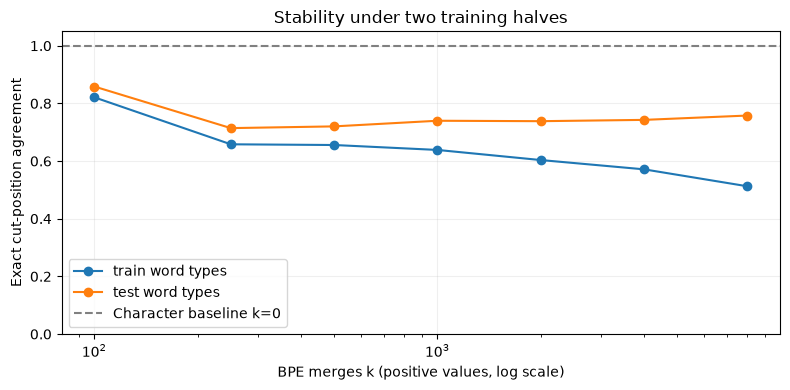

,k,stability,stability eligible types,stability coverage
1,0.0,1.00000,665,1.0
3,100.0,0.85865,665,1.0
5,250.0,0.71429,665,1.0
7,500.0,0.72030,665,1.0
9,1000.0,0.73985,665,1.0
11,2000.0,0.73835,665,1.0
13,4000.0,0.74286,665,1.0
15,8000.0,0.75789,665,1.0


Independent full-training rerun: identical merge list and vocabulary IDs.


,k,strategy,marker,training_seconds
5,0,clean,end,0.087636
6,100,clean,end,0.443221
7,250,clean,end,0.609893
8,500,clean,end,0.626855
0,1000,clean,end,0.554655
3,2000,clean,end,0.614728
9,4000,clean,end,0.877250
10,8000,clean,end,0.960482
11,2000,clean,start,0.635204
2,2000,lower,end,0.594272


Assignment 1 total: 40.60 seconds (0.68 minutes).
8,000-merge training: 0.960 seconds (<600 s).


In [9]:
display(Code(inspect.getsource(measure), language='python'))
display(Code(inspect.getsource(stability), language='python'))
# The requested UNK comparison includes every k and the word baseline on all three corpora.
a1_unknown_table = a1_domain_table[['model', 'k', 'corpus', 'tokens', 'unknown tokens', 'UNK rate']]
with pd.option_context('display.max_rows', 40):
    display(a1_unknown_table.round(6))
a1_unknown_table.to_csv(a1_result_dir / 'unknown_rates.csv', index=False)

a1_accuracy_table = a1_k_table.query("model == 'BPE' and split == 'test'")[['k', 'round-trip accuracy']]
display(a1_accuracy_table)
print('All 400 held-out lines round-trip correctly for all eight clean BPE sizes.')
print('Raw/lower/clean/split and both markers were also checked on all 400 lines at k=2000.')

fig, ax = plt.subplots(figsize=(8, 4))
for split in ['train', 'test']:
    rows = a1_k_table.query("model == 'BPE' and k > 0 and split == @split")
    ax.plot(rows['k'], rows['stability'], marker='o', label=f'{split} word types')
ax.axhline(1, linestyle='--', color='gray', label='Character baseline k=0')
ax.set_xscale('log')
ax.set(xlabel='BPE merges k (positive values, log scale)', ylabel='Exact cut-position agreement',
       title='Stability under two training halves', ylim=(0, 1.05))
ax.legend()
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()
a1_stability_details = a1_k_table.query("model == 'BPE' and split == 'test'")[
    ['k', 'stability', 'stability eligible types', 'stability coverage']]
display(a1_stability_details.round(5))

# Verify determinism again on the complete training split.
a1_repeat = BPETokenizer(1000).train(a1_train_text)
assert a1_repeat.merges == a1_main['tok'].merges
assert a1_repeat.vocab == a1_main['tok'].vocab
print('Independent full-training rerun: identical merge list and vocabulary IDs.')
a1_timing_rows = [dict(k=k, strategy=strategy, marker=marker, training_seconds=record['seconds'])
                  for (k, strategy, marker), record in a1_registry.items()]
a1_timing_table = pd.DataFrame(a1_timing_rows).sort_values(['strategy', 'marker', 'k'])
display(a1_timing_table)
a1_timing_table.to_csv(a1_result_dir / 'training_times.csv', index=False)
A1_SECONDS = time.perf_counter() - A1_START
a1_runtime = dict(seconds=A1_SECONDS, seed=A1_SEED, machine=platform.platform(),
                  python=platform.python_version(), device='CPU',
                  k8000_seconds=a1_registry[(8000, 'clean', 'end')]['seconds'])
(a1_result_dir / 'runtime.json').write_text(json.dumps(a1_runtime, indent=2))
print(f'Assignment 1 total: {A1_SECONDS:.2f} seconds ({A1_SECONDS / 60:.2f} minutes).')
print(f"8,000-merge training: {a1_runtime['k8000_seconds']:.3f} seconds (<600 s).")

# 2: n-grams

### Task 1

Prepare the corpus and tokens.

We reuse the completed Assignment 1 `BPETokenizer` and clean normalization, and the existing shared `evaluation.py` functions used by Assignment 3. The original `n_gram.py` is kept unchanged. Its initialization, training setup, and unigram counting are inherited by the `NGramLM` adapter; tuple keys and line-wise counting supply the required token-ID interface without concatenating ambiguous token strings.

Use a deterministic **80% training / 10% validation / 10% test split by line**, without shuffling. This gives the model most of the data while reserving equally sized validation and test sets. It is the same split already used by Assignment 3. Save the three clean split files, fit BPE only on training lines, and never reuse Assignment 1's 99%-trained merges here, since those would include held-out text.

Each line, including an empty line, is one sequence with `n-1` BOS tokens and one EOS token. BOS is context only; EOS is predicted. Character counts are the lengths of the original clean lines before tokenization, including spaces and punctuation but excluding line separators and synthetic markers. This denominator stays fixed across k and n and matches Assignment 3.

This section now establishes the functions, split, and three prompts previously described as provisional in Assignment 3. Both assignments use the same implementations; no earlier evaluation function is rewritten.

In [10]:
from pathlib import Path
import hashlib
import inspect
import json
import math
import platform
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Code
from bpe import BPETokenizer, normalize
from ngram import NGramLM
from n_gram import NGram
from evaluation import EncodedSequences, encode_lines, encode_file, perplexity, generate
from language_data import load_shakespeare, write_split_files

A2_START = time.perf_counter()
A2_SEED = 42
random.seed(A2_SEED)
np.random.seed(A2_SEED)
a2_results = Path('results/assignment2')
a2_models_dir = Path('models/assignment2')
a2_results.mkdir(parents=True, exist_ok=True)
a2_models_dir.mkdir(parents=True, exist_ok=True)
a2_lines = load_shakespeare()
a2_files = write_split_files(a2_lines)
print(f'Seed {A2_SEED}; {platform.platform()}; CPU')
display(pd.DataFrame([
    {'split': name, 'lines': len(lines), 'characters': sum(map(len, lines)),
     'file SHA-256': hashlib.sha256(a2_files[name].read_bytes()).hexdigest()}
    for name, lines in a2_lines.items()
]))
assert [len(a2_lines[s]) for s in ['train','val','test']] == [32000,4000,4000]
a2_tokenizers = {}
a2_tokenizer_times = {}
a2_encoded = {}
def a2_tokenizer(k):
    if k not in a2_tokenizers:
        started = time.perf_counter()
        tokenizer = BPETokenizer(num_merges=k).train('\n'.join(a2_lines['train']))
        a2_tokenizer_times[k] = time.perf_counter() - started
        tokenizer.save(a2_models_dir / f'bpe_{k}.json')
        a2_tokenizers[k] = tokenizer
    return a2_tokenizers[k]

def a2_sequences(k, n, split):
    key = (k, n, split)
    if key not in a2_encoded:
        a2_encoded[key] = encode_file(a2_tokenizer(k), a2_files[split], n=n)
    return a2_encoded[key]

a2_tok = a2_tokenizer(1000)
a2_initial_ids = {split: a2_sequences(1000, 3, split) for split in a2_lines}
print('Initial k=1000; V =', len(a2_tok.vocab))
display(pd.DataFrame([
    {'split': split, 'sequences': len(sequences),
     'predicted tokens (including EOS)': sum(len(s)-2 for s in sequences),
     'UNK tokens': sum(s.count(a2_tok.unk_id) for s in sequences)}
    for split, sequences in a2_initial_ids.items()
]))
print('Example padded sequence:', a2_initial_ids['train'][0])
print('Symbols:', [a2_tok._id_to_token[i] for i in a2_initial_ids['train'][0]])
assert all(s[:2] == [a2_tok.bos_id]*2 and s[-1] == a2_tok.eos_id
           for sequences in a2_initial_ids.values() for s in sequences)

Seed 42; macOS-15.7.1-arm64-arm-64bit; CPU


,split,lines,characters,file SHA-256
0,train,32000,875150,e4c055399b607de2a4f58b4e877441eaa7d3fe4ff6f813...
1,val,4000,105074,ed866c069ef1b5c94d9865c2a8dc945a4edaf62c248105...
2,test,4000,95152,b0ebc588f356579b269b4f6bbcaf94f4087212307f95de...


Initial k=1000; V = 1043


,split,sequences,predicted tokens (including EOS),UNK tokens
0,train,32000,460656,0
1,val,4000,57506,0
2,test,4000,53483,0


Example padded sequence: [0, 0, 381, 5, 813, 1]
Symbols: ['<bos>', '<bos>', 'first</w>', ' ', 'citizen:</w>', '<eos>']


### Task 2

The n-gram engine and hand checks.

For every supported order $n\in\{1,2,3\}$, use add-one smoothing everywhere:

$$P(w\mid h)=\frac{c(h,w)+1}{c(h)+V}.$$

An unseen history has both counts zero, giving exactly $1/V$ for every token. For a unigram the history is the empty tuple and its count is the total number of predicted tokens. Count histories only at positions with a target, so the outgoing n-gram counts sum to their history count. Sequence boundaries prevent EOS from becoming the history of the following line.

The adapter retains our original `NGram.__init__`, `NGram.train`, and `count_unigrams` methods. The original higher-order counters concatenate strings (which loses boundaries), or add integer IDs if passed IDs, so they cannot be reused unchanged for this interface. All model code uses only the standard library and NumPy.

Toy corpus: **ab, ab, ac, b, a**. IDs are BOS=0, EOS=1, UNK=2, a=3, b=4, c=5, so V=6. In the bigram model, history a occurs four times and is followed by b twice, giving $P(b\mid a)=(2+1)/(4+6)=0.3$. History b occurs three times and is always followed by EOS, giving $P(\mathrm{EOS}\mid b)=(3+1)/(3+6)=4/9$.

In [11]:
display(Code(inspect.getsource(NGramLM), language='python'))
print('Original unigram counter, inherited unchanged:')
display(Code(inspect.getsource(NGram.count_unigrams), language='python'))
a2_toy_words = [[3,4], [3,4], [3,5], [4], [3]]
a2_toy_models = {}
for order in [1,2,3]:
    sequences = EncodedSequences([[0]*(order-1) + word + [1] for word in a2_toy_words], 8)
    lm = NGramLM(n=order, vocab_size=6).fit(sequences)
    a2_toy_models[order] = lm
    assert sum(lm.ngram_counts.values()) == 13  # eight characters plus five EOS
    assert sum(lm.context_counts.values()) == 13
    for history in lm.context_counts:
        assert np.isclose(np.exp(lm.next_token_log_probs(history)).sum(), 1.0)
        assert sum(lm.ngram_counts[history+(t,)] for t in range(6)) == lm.context_counts[history]
        assert 1 not in history  # no contexts cross a line boundary
    if order > 1:
        assert np.allclose(np.exp(lm.next_token_log_probs([2]*(order-1))), np.full(6,1/6))
assert a2_toy_models[1].context_counts[()] == 13
assert np.isclose(np.exp(a2_toy_models[1].log_prob(3, [])), 5/19)
a2_manual = pd.DataFrame([
    {'probability': 'P(b | a)', 'by hand': 3/10,
     'code': np.exp(a2_toy_models[2].log_prob(4, [3]))},
    {'probability': 'P(EOS | b)', 'by hand': 4/9,
     'code': np.exp(a2_toy_models[2].log_prob(1, [4]))},
])
display(a2_manual)
assert np.allclose(a2_manual['by hand'], a2_manual['code'])
print('All three orders, normalized distributions, unseen histories, and both hand calculations passed.')

class NGramLM(NGram):
    def __init__(self, n, vocab_size):
        super().__init__(n)
        self.vocab_size = vocab_size
        self.vocabulary_size = vocab_size
        self.ngram_counts = Counter()
        self.context_counts = Counter()

    def fit(self, sequences):
        super().train([t for sequence in sequences for t in sequence[self.n - 1:]])
        self.vocabulary_size = self.vocab_size
        self.unigram_counts = self.count_unigrams()
        self.ngram_counts.clear()
        self.context_counts.clear()
        for sequence in sequences:
            for i in range(self.n - 1, len(sequence)):
                context = tuple(sequence[i - self.n + 1:i])
                self.ngram_counts[context + (sequence[i],)] += 1
                self.context_counts[context] += 1
        return self

    def log_prob(self, token, context):
        context = tuple(context)
        return math.log((self.ngram_counts[context + (token,)] + 1) /
                        (self.context_counts[context] + self.vocab_size))

    def next_token_log_probs(self, context):
        return np.array([self.log_prob(token, context) for token in range(self.vocab_size)])

    @property
    def stored_counts(self):
        return len(self.ngram_counts) + len(self.context_counts) + len(self.unigram_counts)

Original unigram counter, inherited unchanged:


def count_unigrams(self):
        return Counter(self.corpus)

,probability,by hand,code
0,P(b | a),0.300000,0.300000
1,P(EOS | b),0.444444,0.444444


All three orders, normalized distributions, unseen histories, and both hand calculations passed.


### Task 3

Shared perplexity and the unigram sanity check.

`perplexity` is model-independent: it calls `log_prob` and never accesses count dictionaries. Accumulate negative log probabilities, then exponentiate:

$$\mathrm{PP}=\exp(\mathrm{NLL}/N),\qquad\mathrm{PP}_{char}=\exp(\mathrm{NLL}/C).$$

$N$ includes EOS but excludes BOS. $C$ counts the clean original characters before tokenization, excluding separators and markers. `EncodedSequences` is a list of ID sequences carrying this character count. Use PP/character to compare different k values because their predicted units have different lengths.

For the random-data check, save exactly **200 seeded uniform content-token IDs** to JSON, read them back, and append one EOS for evaluation (201 predicted tokens). Exclude special and empty-decoding tokens from random content. Its character denominator is the length of the decoded random content; that per-character value is only a synthetic sanity check, not a natural-text benchmark.

In [12]:
display(Code(inspect.getsource(perplexity), language='python'))
a2_unigram = NGramLM(1, len(a2_tok.vocab)).fit(a2_sequences(1000,1,'train'))
a2_train_pp = perplexity(a2_unigram, a2_sequences(1000,1,'train'))
a2_rng = np.random.default_rng(A2_SEED)
a2_content_ids = [i for i in range(len(a2_tok.vocab))
                  if i not in [a2_tok.bos_id,a2_tok.eos_id,a2_tok.unk_id] and a2_tok.decode([i])]
a2_random_ids = a2_rng.choice(a2_content_ids, size=200).tolist()
a2_random_file = a2_results / 'random_200_ids.json'
a2_random_file.write_text(json.dumps(a2_random_ids))
a2_random_ids = json.loads(a2_random_file.read_text())
assert len(a2_random_ids) == 200
a2_random_sequences = EncodedSequences([a2_random_ids+[a2_tok.eos_id]],
                                      len(a2_tok.decode(a2_random_ids)))
a2_random_pp = perplexity(a2_unigram, a2_random_sequences)
display(pd.DataFrame([a2_train_pp,a2_random_pp],
    index=['Unigram on its training text','Unigram on 200 random IDs + EOS'],
    columns=['PP/token','PP/character']))
display(Markdown(f"The training PP/token is {a2_train_pp[0]:.3f}: frequent training tokens receive more probability, so this measures fit to the learned frequency distribution."))
display(Markdown(f"The random-file PP/token is {a2_random_pp[0]:.3f}: uniform token sampling presents rare training tokens more often and therefore produces a larger cross-entropy than the training text."))
assert a2_random_pp[0] > a2_train_pp[0]
# A uniform model gives an exact independent check of both denominators.
class A2UniformModel:
    n = 3
    def log_prob(self, token, context):
        return -math.log(6)
a2_uniform_ids = EncodedSequences([[0,0,3,4,1]], character_count=2)
assert np.allclose(perplexity(A2UniformModel(),a2_uniform_ids),(6,6**1.5))
print('Uniform-model check: 3 predictions / 2 original characters; BOS excluded, EOS included.')

def perplexity(model, sequences):
    negative_log_likelihood, predicted_tokens = 0.0, 0
    for sequence in sequences:
        for i in range(model.n - 1, len(sequence)):
            context = sequence[i - model.n + 1:i]
            negative_log_likelihood -= model.log_prob(sequence[i], context)
            predicted_tokens += 1
    if predicted_tokens == 0 or sequences.character_count <= 0:
        raise ValueError("Perplexity needs predicted tokens and a positive character count.")
    return (math.exp(negative_log_likelihood / predicted_tokens),
            math.exp(negative_log_likelihood / sequences.character_count))

,PP/token,PP/character
Unigram on its training text,122.380759,12.557912
Unigram on 200 random IDs + EOS,2977.770318,10.825491


The training PP/token is 122.381: frequent training tokens receive more probability, so this measures fit to the learned frequency distribution.

The random-file PP/token is 2977.770: uniform token sampling presents rare training tokens more often and therefore produces a larger cross-entropy than the training text.

Uniform-model check: 3 predictions / 2 original characters; BOS excluded, EOS included.


### Task 4

Validation-only model selection.

Train all 15 combinations: `k ∈ {250, 500, 1000, 2000, 4000}` and `n ∈ {1, 2, 3}`. Every BPE tokenizer and count model sees training text only. Choose the pair with the lowest **validation PP/character**, breaking exact ties by smaller n then k. Freeze that choice before computing any test perplexity; the test UNK counts shown in Task 1 are a data check, not a model score.

After selection, evaluate the three orders at the selected k on the test set exactly once each. Keep the choice even if another order happens to score better on the test set. No retraining on validation data is performed.

n=1, k=250: validation PP/token=86.092; PP/character=19.859


n=2, k=250: validation PP/token=21.433; PP/character=7.814


n=3, k=250: validation PP/token=22.596; PP/character=8.096


n=1, k=500: validation PP/token=106.991; PP/character=16.532


n=2, k=500: validation PP/token=30.991; PP/character=7.857


...

n=1, k=4000: validation PP/token=143.438; PP/character=10.058


n=2, k=4000: validation PP/token=186.634; PP/character=11.367


n=3, k=4000: validation PP/token=355.855; PP/character=15.343


k,250,500,1000,2000,4000
n,,,,,
1,19.8592,16.5324,14.1284,11.5212,10.0575
2,7.8142,7.8573,8.5712,9.8214,11.3667
3,8.0961,9.5761,11.6314,13.3505,15.3433


,n,k,V,validation_pp,validation_pp_char,stored_counts,training_seconds
0,1,250,293,86.09227,19.85922,579,0.13477
1,2,250,293,21.43301,7.81416,9076,0.17531
2,3,250,293,22.59594,8.09609,57753,0.19770
3,1,500,543,106.99139,16.53238,1077,0.12728
4,2,500,543,30.99110,7.85735,13949,0.16511
5,3,500,543,43.08632,9.57610,84159,0.18264
6,1,1000,1043,126.30857,14.12844,2063,0.11851
7,2,1000,1043,50.67979,8.57116,20527,0.15070
8,3,1000,1043,88.53280,11.63139,111761,0.17390
9,1,2000,2043,136.76112,11.52117,4043,0.10427


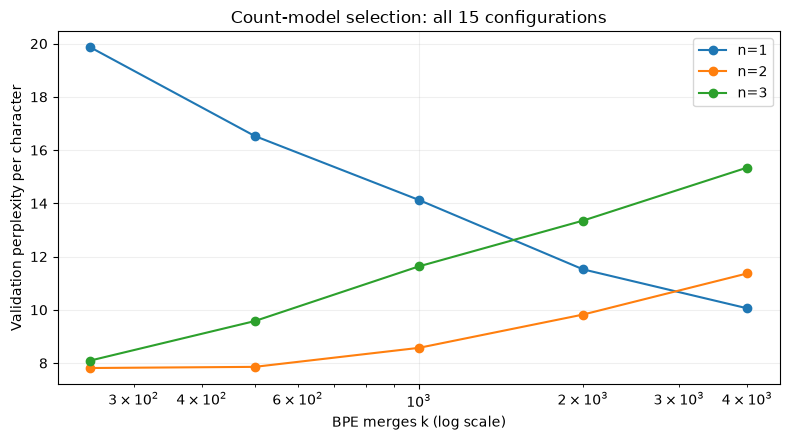

Validation selects **n=2, k=250**, with PP/character 7.8142. The curves show that n=1 falls with k; n=2 rises with k; n=3 rises with k, reflecting the trade-off between longer tokens and sparser counts under add-one smoothing.

Choice frozen before any test perplexity is computed.


In [13]:
A2_KS = [250,500,1000,2000,4000]
a2_grid_models = {}
a2_grid_rows = []
for k in A2_KS:
    tokenizer = a2_tokenizer(k)
    for order in [1,2,3]:
        train_sequences = a2_sequences(k,order,'train')
        validation_sequences = a2_sequences(k,order,'val')
        started = time.perf_counter()
        candidate = NGramLM(order,len(tokenizer.vocab)).fit(train_sequences)
        fit_seconds = time.perf_counter() - started
        pp, pp_char = perplexity(candidate,validation_sequences)
        a2_grid_models[(order,k)] = candidate
        a2_grid_rows.append(dict(n=order,k=k,V=len(tokenizer.vocab),
            validation_pp=pp,validation_pp_char=pp_char,
            stored_counts=candidate.stored_counts,training_seconds=fit_seconds))
        print(f'n={order}, k={k}: validation PP/token={pp:.3f}; PP/character={pp_char:.3f}',flush=True)
a2_grid = pd.DataFrame(a2_grid_rows)
a2_validation_table = a2_grid.pivot(index='n',columns='k',values='validation_pp_char')
display(a2_validation_table.round(4))
display(a2_grid.round(5))
fig, ax = plt.subplots(figsize=(8,4.5))
for order in [1,2,3]:
    rows = a2_grid.query('n == @order').sort_values('k')
    ax.plot(rows['k'],rows['validation_pp_char'],marker='o',label=f'n={order}')
ax.set_xscale('log')
ax.set(xlabel='BPE merges k (log scale)',ylabel='Validation perplexity per character',
       title='Count-model selection: all 15 configurations')
ax.legend()
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()
a2_winner = min(a2_grid_rows,key=lambda row:(row['validation_pp_char'],row['n'],row['k']))
a2_best_n,a2_best_k = a2_winner['n'],a2_winner['k']
a2_best_model = a2_grid_models[(a2_best_n,a2_best_k)]
a2_best_tok = a2_tokenizers[a2_best_k]
(a2_results/'selection_before_test.json').write_text(json.dumps(a2_winner,indent=2))
a2_shapes=[]
for order in [1,2,3]:
    values=a2_validation_table.loc[order].to_numpy()
    shape='rises with k' if np.all(np.diff(values)>=0) else 'falls with k' if np.all(np.diff(values)<=0) else 'is non-monotonic'
    a2_shapes.append(f'n={order} {shape}')
display(Markdown(f"Validation selects **n={a2_best_n}, k={a2_best_k}**, with PP/character {a2_winner['validation_pp_char']:.4f}. The curves show that {'; '.join(a2_shapes)}, reflecting the trade-off between longer tokens and sparser counts under add-one smoothing."))
print('Choice frozen before any test perplexity is computed.')
a2_grid.to_csv(a2_results/'validation_grid_long.csv',index=False)
a2_validation_table.to_csv(a2_results/'validation_grid.csv')

In [14]:
# Final test phase: one evaluation per requested model at the chosen k.
a2_test_rows=[]
for order in [1,2,3]:
    pp,pp_char=perplexity(a2_grid_models[(order,a2_best_k)],a2_sequences(a2_best_k,order,'test'))
    a2_test_rows.append(dict(n=order,k=a2_best_k,selected_on_validation=order==a2_best_n,
                             test_pp=pp,test_pp_char=pp_char))
a2_test_table=pd.DataFrame(a2_test_rows)
display(a2_test_table.round(5))
a2_test_table.to_csv(a2_results/'test_comparison.csv',index=False)
print('The validation-selected model is retained; test results do not change the choice.')

,n,k,selected_on_validation,test_pp,test_pp_char
0,1,250,False,87.11065,20.62280
1,2,250,True,23.47393,8.48274
2,3,250,False,27.28340,9.39256


The validation-selected model is retained; test results do not change the choice.


### Task 5

Generation and stopping behavior.

Use the selected model and the same three prompts as Assignment 3: **shall i compare thee**, **to be or not to be**, and **first citizen**. Produce ten outputs per mode, cycling through the prompts in the same order (4/3/3 outputs across prompts), with seed `42+i` and a 50-token limit. The shared `generate` function normalizes and encodes the prompt, supplies BOS context, calls the model's probability interface, and either samples or takes argmax. It returns decoded text with an explicit EOS/limit stopping reason.

To count loops without changing generation, a small wrapper records contexts passed to the model. For deterministic argmax with a fixed context window, a repeated context before EOS proves a cycle: the same next token and subsequent contexts recur. Report that as an argmax loop. For sampling, report how many outputs reach EOS in fewer than 50 generated tokens; repeated contexts alone do not prove a sampling loop. The generator itself contains no count-model logic.

In [15]:
display(Code(inspect.getsource(generate),language='python'))
class A2GenerationTrace:
    def __init__(self, model):
        self.model=model
        self.n=model.n
        self.contexts=[]
    def next_token_log_probs(self,context):
        self.contexts.append(tuple(context))
        return self.model.next_token_log_probs(context)

a2_prompts=['shall i compare thee','to be or not to be','first citizen']
a2_samples=[]
for mode in ['argmax','sample']:
    for i in range(10):
        prompt=a2_prompts[i%3]
        trace=A2GenerationTrace(a2_best_model)
        text=generate(trace,a2_best_tok,prompt,mode=mode,max_tokens=50,seed=A2_SEED+i)
        reached_eos=text.endswith(' [stopped: <eos>]')
        loop=(mode=='argmax' and len(set(trace.contexts))<len(trace.contexts))
        a2_samples.append(dict(mode=mode,number=i+1,prompt=prompt,seed=A2_SEED+i,
            generated_tokens=len(trace.contexts),argmax_loop=loop,
            eos_before_limit=reached_eos and len(trace.contexts)<50,text=text))
        print(f'\n{mode.upper()} {i+1} | seed={A2_SEED+i} | prompt={prompt!r}')
        print(text)
a2_generation_table=pd.DataFrame(a2_samples)
a2_generation_summary=a2_generation_table.groupby('mode').agg(
    outputs=('text','size'),argmax_loops=('argmax_loop','sum'),
    sample_or_argmax_EOS_before_limit=('eos_before_limit','sum'))
display(a2_generation_summary)
# Same seed and prompt must reproduce the sampled output exactly.
first_sample=a2_generation_table.query("mode == 'sample'").iloc[0]
assert generate(a2_best_model,a2_best_tok,first_sample['prompt'],mode='sample',
                max_tokens=50,seed=int(first_sample['seed'])) == first_sample['text']
a2_generation_table.to_csv(a2_results/'generation.csv',index=False)
a2_generation_summary.to_csv(a2_results/'generation_summary.csv')
# Refit the chosen model and compare its validation score and counts.
a2_repeat=NGramLM(a2_best_n,len(a2_best_tok.vocab)).fit(a2_sequences(a2_best_k,a2_best_n,'train'))
assert a2_repeat.ngram_counts == a2_best_model.ngram_counts
assert a2_repeat.context_counts == a2_best_model.context_counts
assert perplexity(a2_repeat,a2_sequences(a2_best_k,a2_best_n,'val'))[1] == a2_winner['validation_pp_char']
print('Reproducibility checks passed for counts, validation perplexity, and seeded generation.')
A2_SECONDS=time.perf_counter()-A2_START
a2_runtime=dict(seconds=A2_SECONDS,seed=A2_SEED,machine=platform.platform(),
    python=platform.python_version(),device='CPU',split='80/10/10 by line',
    selected_n=a2_best_n,selected_k=a2_best_k)
(a2_results/'runtime.json').write_text(json.dumps(a2_runtime,indent=2))
print(f'Assignment 2 complete: {A2_SECONDS:.2f} seconds.')

def generate(model, tokenizer, prompt, mode="sample", max_tokens=50, seed=0):
    if mode not in {"sample", "argmax"}:
        raise ValueError("mode must be sample or argmax")
    rng = np.random.default_rng(seed)
    ids = [tokenizer.bos_id] * (model.n - 1) + tokenizer.encode(normalize(prompt))
    for _ in range(max_tokens):
        context = ids[-(model.n - 1):] if model.n > 1 else []
        log_probs = model.next_token_log_probs(context)
        if mode == "argmax":
            token = int(np.argmax(log_probs))
        else:
            probabilities = np.exp(log_probs - np.max(log_probs))
            probabilities /= probabilities.sum()
            token = int(rng.choice(len(probabilities), p=probabilities))
        ids.append(token)
        if token == tokenizer.eos_id:
            return tokenizer.decode(ids) + " [stopped: <eos>]"
    return tokenizer.decode(ids) + f" [stopped: {max_tokens}-token limit]"


ARGMAX 1 | seed=42 | prompt='shall i compare thee'
shall i compare thee the the the the the the the the the the the the the the the the the the the the the the the the the [stopped: 50-token limit]

ARGMAX 2 | seed=43 | prompt='to be or not to be'
to be or not to be the the the the the the the the the the the the the the the the the the the the the the the the the [stopped: 50-token limit]

ARGMAX 3 | seed=44 | prompt='first citizen'
first citizen the the the the the the the the the the the the the the the the the the the the the the the the the [stopped: 50-token limit]

ARGMAX 4 | seed=45 | prompt='shall i compare thee'
shall i compare thee the the the the the the the the the the the the the the the the the the the the the the the the the [stopped: 50-token limit]

ARGMAX 5 | seed=46 | prompt='to be or not to be'
to be or not to be the the the the the the the the the the the the the the the the the the the the the the the the the [stopped: 50-token limit]

ARGMAX 6 | seed=47 | promp

,outputs,argmax_loops,sample_or_argmax_EOS_before_limit
mode,,,
argmax,10,10,0
sample,10,0,9


Reproducibility checks passed for counts, validation perplexity, and seeded generation.


Assignment 2 complete: 10.07 seconds.


# 3: Neural n-grams

### Task 1

Prepare the token streams and batches.

**Reuse and missing prerequisites.** `neural_n_gram.py`, `n_gram.py`, and `byte_pair_encoder.py` are exact copies of our original files. The network below directly inherits our original layers and forward computation. The new `neural_ngram.py` adds the assignment interface; the training loop changes from SGD to the required AdamW. Our original tokenizer did not support applying saved merges to new text, and no `perplexity`/`generate`, split files, or prompts were supplied. The supporting `bpe.py`, `evaluation.py`, and `ngram.py` therefore provide the missing functionality, reusing original helpers where correct. **These additions are not claimed to be unchanged Assignment 2 functions.** Replace these prerequisites with the actual Assignment 2 versions if those exist elsewhere; the assignment explicitly requires reuse.

Assignment 1 is now also complete and supplies the shared BPE implementation. Assignments 2 and 4 remain untouched; the earlier evaluation functions, prompts, and split files were still not supplied.

**Data conventions.** As no previous split was supplied, use a documented provisional 80/10/10 split by line, without shuffling: enough training data and equally sized held-out sets. Apply lowercase, NFKC, digit-to-`0`, and whitespace normalization. Each line, including empty lines, gets two `<bos>` tokens and one `<eos>`. Fit BPE on training text only, never across word boundaries. Explicit space tokens preserve normalized spacing. Character counts include spaces and punctuation in normalized lines, but exclude newline separators and synthetic markers. Keep this denominator identical for all values of `k` and both models.

Flatten each split but retain valid target positions. This preserves the line boundaries: `<bos>` is context only, `<eos>` is predicted, and no training window crosses into the previous line.

In [16]:
from pathlib import Path
import hashlib
import inspect
import json
import math
import platform
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display, Markdown

from bpe import BPETokenizer, normalize
from evaluation import encode_lines, perplexity, generate
from ngram import NGramLM
from neural_ngram import NeuralNGramLM
from neural_n_gram import NeuralNGram
from assignment3_utils import (
    WindowData, batched_perplexity, load_shakespeare,
    download_if_missing, PTB_URL, PTB_MD5,
)

NOTEBOOK_START = time.perf_counter()
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)  # faster for these small CPU matrix operations
# CPU is the measured/submitted default. All tensors use this one device.
device = 'cpu'
# Optional for a separate run: device = 'cuda' if torch.cuda.is_available() else 'cpu'
N = 3
BASE = dict(n=3, k=1000, n_embd=64, n_hidden=256,
            batch_size=64, lr=1e-3, max_steps=2000)
print(f'Seed: {SEED}; device: {device}; PyTorch: {torch.__version__}')
print(f'Machine: {platform.platform()} / {platform.machine()}')

lines = load_shakespeare()
display(pd.DataFrame([
    {'split': name, 'lines': len(part), 'characters': sum(map(len, part))}
    for name, part in lines.items()
]))

data_by_k = {}
def prepare_data(k):
    if k not in data_by_k:
        started = time.perf_counter()
        tokenizer = BPETokenizer(num_merges=k).train('\n'.join(lines['train']))
        tokenizer.save(f'models/bpe_{k}.json')
        encoded = {name: encode_lines(tokenizer, part, n=N)
                   for name, part in lines.items()}
        data_by_k[k] = dict(tok=tokenizer, ids=encoded,
            windows={name: WindowData(ids, N) for name, ids in encoded.items()},
            tokenizer_seconds=time.perf_counter() - started)
    return data_by_k[k]

base_data = prepare_data(BASE['k'])
tok = base_data['tok']
train_ids, val_ids, test_ids = (base_data['ids'][name] for name in ('train', 'val', 'test'))
windows = base_data['windows']
V = len(tok.vocab)
print(f'k={BASE["k"]}, learned merges={len(tok.merges)}, V={V}')
display(pd.DataFrame([
    {'split': name, 'flat_tokens': len(windows[name].flat_ids),
     'predicted_tokens': len(windows[name].target_positions),
     'unknown_tokens': sum(seq.count(tok.unk_id) for seq in ids)}
    for name, ids in base_data['ids'].items()
]))

Seed: 42; device: cpu; PyTorch: 2.14.0
Machine: macOS-15.7.1-arm64-arm-64bit / arm64


,split,lines,characters
0,train,32000,875150
1,val,4000,105074
2,test,4000,95152


k=1000, learned merges=1000, V=1043


,split,flat_tokens,predicted_tokens,unknown_tokens
0,train,524656,460656,0
1,val,65506,57506,0
2,test,61483,53483,0


In [17]:
def get_batch(split, batch_size, generator=None):
    # Accept a split name for Task 1, or explicit training/validation windows later.
    data = windows[split] if isinstance(split, str) else split
    rows = torch.randint(len(data.target_positions), (batch_size,), generator=generator)
    return data.at(rows, device)

x_demo, y_demo = get_batch('train', 4, torch.Generator().manual_seed(SEED))
print('x =', x_demo, '\ny =', y_demo)
print('shapes:', tuple(x_demo.shape), tuple(y_demo.shape))
print('dtypes:', x_demo.dtype, y_demo.dtype, '; devices:', x_demo.device, y_demo.device)
print('first context tokens:', [tok._id_to_token[i] for i in x_demo[0].tolist()])
print('next token:', repr(tok._id_to_token[y_demo[0].item()]))
print('decoded context:', repr(tok.decode(x_demo[0].tolist())))
print('decoded context + target:', repr(tok.decode(x_demo[0].tolist() + [y_demo[0].item()])))
assert x_demo.shape == (4, N - 1) and y_demo.shape == (4,)
assert x_demo.dtype == y_demo.dtype == torch.long

# A small ID stream that can be checked by hand.
# IDs 0=<bos>, 1=<eos>, 2='a', 3='b', 4='c'.
from evaluation import EncodedSequences
toy = WindowData(EncodedSequences([[0, 0, 2, 3, 4, 1]], character_count=3), n=3)
toy_x, toy_y = toy.at(torch.arange(4), device)
print('Toy contexts:', toy_x.tolist(), '; targets:', toy_y.tolist())
print("By hand: context [2, 3] = 'ab'; the next ID is 4 = 'c'.")
assert toy_x[2].tolist() == [2, 3] and toy_y[2].item() == 4

x = tensor([[135,   5],
        [ 21,  52],
        [  5, 153],
        [ 83, 101]]) 
y = tensor([ 61, 242,   5,  59])
shapes: (4, 2) (4,)
dtypes: torch.int64 torch.int64 ; devices: cpu cpu
first context tokens: ['y,</w>', ' ']
next token: 'the</w>'
decoded context: 'y, '
decoded context + target: 'y, the'
Toy contexts: [[0, 0], [0, 2], [2, 3], [3, 4]] ; targets: [2, 3, 4, 1]
By hand: context [2, 3] = 'ab'; the next ID is 4 = 'c'.


### Task 2

The neural model and common interface.

Our existing `NeuralNGram.__init__` and `NeuralNGram.forward` remain unchanged: embedding → flatten → hidden linear layer → ReLU → vocabulary logits. `F.relu` in the original is the same operation as `nn.ReLU`. The adapter accepts the required `(n, vocab_size, n_embd, n_hidden)` arguments and adds targets, cross-entropy loss, and the two inference methods. Its inference methods use evaluation mode and disable gradients. Stable log-softmax computes log probabilities without taking the logarithm of an underflowed softmax.

The model never receives the target as input. Before training, approximately uniform predictions should give cross-entropy close to `ln(V)`.

In [18]:
print('Original forward method, reused without changes:')
print(inspect.getsource(NeuralNGram.forward))
print('Assignment 3 adapter:')
print(inspect.getsource(NeuralNGramLM))

torch.manual_seed(SEED)
model = NeuralNGramLM(n=N, vocab_size=V, n_embd=64, n_hidden=256).to(device)
xb, yb = get_batch('train', 1024, torch.Generator().manual_seed(SEED + 1))
with torch.no_grad():
    logits, initial_loss = model(xb, yb)
print(model)
print(f'Initial loss: {initial_loss.item():.4f}; ln(V): {math.log(V):.4f}')
assert logits.shape == (1024, V)
assert model(xb)[1] is None
assert abs(initial_loss.item() - math.log(V)) < 0.5
assert np.isclose(np.exp(model.next_token_log_probs(xb[0].tolist())).sum(), 1.0)

# Compare the unchanged shared scalar evaluator with its neural batched equivalent.
# All characters and all EOS predictions in this short validation slice are counted.
check_ids = encode_lines(tok, lines['val'][:20], n=N)
scalar_pp = perplexity(model, check_ids)
batch_pp = batched_perplexity(model, check_ids)
display(pd.DataFrame([scalar_pp, batch_pp],
    index=['Shared scalar evaluator', 'Batched neural evaluator'],
    columns=['PP/token', 'PP/character']).round(3))
assert tuple(round(v, 3) for v in scalar_pp) == tuple(round(v, 3) for v in batch_pp)

Original forward method, reused without changes:
    def forward(self, inputs):
        # get embeddings of the last n-1 words and concatenates them into one vector
        input_embeddings = self.embeddings(inputs).view(inputs.size(0), -1) # (batch_size, (n-1)*embedding_size)

        # pass the input through the input and hidden layer
        input_layer_output = F.relu(self.input_layer(input_embeddings))
        logits = self.hidden_layer(input_layer_output)
        return logits

Assignment 3 adapter:
class NeuralNGramLM(NeuralNGram):
    def __init__(self, n, vocab_size, n_embd=64, n_hidden=256):
        if n < 2 or vocab_size < 1:
            raise ValueError("Use n >= 2 and a nonempty vocabulary.")
        # The original constructor creates precisely the required layers.
        # Token IDs already come from BPE, so no string-to-index conversion is needed.
        super().__init__(n, n_embd, n_hidden, corpus=range(vocab_size))
        self.vocab_size = vocab_size

    def forwar

,PP/token,PP/character
Shared scalar evaluator,1228.759,44.644
Batched neural evaluator,1228.759,44.644


### Task 3

Training and evaluation.

Use the starting configuration exactly: `n=3`, `k=1000`, `n_embd=64`, `n_hidden=256`, `batch_size=64`, `lr=1e-3`, and `max_steps=2000`. AdamW uses weight decay `0.01`. Training batches use a separate seeded generator. Loss estimates use fixed random batches so changes in the plot reflect the model rather than a different set of evaluation examples. Evaluation never advances the training batch generator. The reported time includes loss estimation and excludes BPE/data preparation. Each run uses its final step; validation is not used for early stopping.

In [19]:
@torch.no_grad()
def estimate_loss(model, train_data, validation_data, batch_size=64, eval_batches=20):
    model.eval()
    estimates = {}
    generator = torch.Generator().manual_seed(SEED + 100)
    for split, data in [('train', train_data), ('val', validation_data)]:
        losses = []
        for _ in range(eval_batches):
            xb, yb = get_batch(data, batch_size, generator)
            _, loss = model(xb, yb)
            losses.append(loss.item())
        estimates[split] = float(np.mean(losses))
    model.train()
    return estimates


def train(model, train_ids, max_steps=2000, lr=1e-3, batch_size=64,
          validation_ids=None, eval_interval=250):
    if validation_ids is None:
        validation_ids = val_ids
    train_data = WindowData(train_ids, model.n)
    validation_data = WindowData(validation_ids, model.n)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    generator = torch.Generator().manual_seed(SEED)
    history = []
    started = time.perf_counter()
    model.train()
    for step in range(max_steps + 1):
        if step % eval_interval == 0 or step == max_steps:
            losses = estimate_loss(model, train_data, validation_data, batch_size)
            history.append(dict(step=step, **losses))
            print(f"step {step:4d}: train={losses['train']:.4f}, val={losses['val']:.4f}", flush=True)
        if step == max_steps:
            break
        xb, yb = get_batch(train_data, batch_size, generator)
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    seconds = time.perf_counter() - started
    print(f'Training time: {seconds:.2f} seconds on {device}', flush=True)
    if seconds >= 300:
        raise RuntimeError('A run exceeded five minutes: reduce the common max_steps and rerun all experiments.')
    return pd.DataFrame(history), seconds


runs = {}
def run_experiment(name, **changes):
    config = {**BASE, **changes}
    data = prepare_data(config['k'])
    torch.manual_seed(SEED)
    candidate = NeuralNGramLM(config['n'], len(data['tok'].vocab),
        config['n_embd'], config['n_hidden']).to(device)
    print(f'\n{name}: {config}', flush=True)
    history, seconds = train(candidate, data['ids']['train'],
        max_steps=config['max_steps'], lr=config['lr'], batch_size=config['batch_size'],
        validation_ids=data['ids']['val'])
    pp, pp_char = batched_perplexity(candidate, data['ids']['val'])
    run = dict(name=name, config=config, model=candidate, history=history,
               train_seconds=seconds, val_pp=pp, val_pp_char=pp_char,
               parameters=sum(p.numel() for p in candidate.parameters()))
    runs[name] = run
    return run

baseline = run_experiment('baseline_k1000')
model = baseline['model']


baseline_k1000: {'n': 3, 'k': 1000, 'n_embd': 64, 'n_hidden': 256, 'batch_size': 64, 'lr': 0.001, 'max_steps': 2000}


step    0: train=7.0809, val=7.0958


step  250: train=4.1966, val=4.1195


step  500: train=3.9522, val=3.8890


step  750: train=3.7807, val=3.7448


...

step 1250: train=3.5331, val=3.5468


step 1500: train=3.4322, val=3.4644


step 1750: train=3.3647, val=3.4161


step 2000: train=3.3090, val=3.3788


Training time: 1.70 seconds on cpu


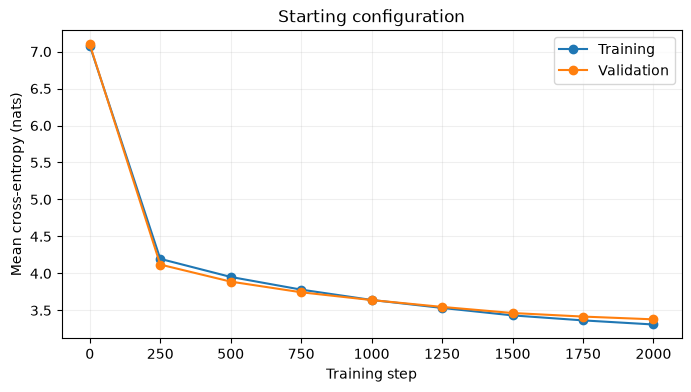

Validation loss is lowest at the final measurement (step 2000); a sustained plateau is not established within this run.

One CPU run: 1.70 s (<300 s).
After training, scalar / batched: ['29.654', '6.111'] ['29.654', '6.111']


In [20]:
history = baseline['history']
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['step'], history['train'], marker='o', label='Training')
ax.plot(history['step'], history['val'], marker='o', label='Validation')
ax.set(xlabel='Training step', ylabel='Mean cross-entropy (nats)', title='Starting configuration')
ax.legend()
ax.grid(alpha=0.2)
plt.show()
minimum = history.loc[history['val'].idxmin()]
if int(minimum['step']) == BASE['max_steps']:
    explanation = f"Validation loss is lowest at the final measurement (step {int(minimum['step'])}); a sustained plateau is not established within this run."
else:
    explanation = f"The lowest measured validation loss occurs at step {int(minimum['step'])}; later measurements do not improve on that value."
display(Markdown(explanation))
print(f"One CPU run: {baseline['train_seconds']:.2f} s (<300 s).")

# Also check the two evaluation paths after training.
scalar_pp = perplexity(model, check_ids)
batch_pp = batched_perplexity(model, check_ids)
print('After training, scalar / batched:', [f'{v:.3f}' for v in scalar_pp],
      [f'{v:.3f}' for v in batch_pp])
assert tuple(round(v, 3) for v in scalar_pp) == tuple(round(v, 3) for v in batch_pp)

### Task 4

Experiments and model selection.

All choices use **validation perplexity per character**. First run the `k` comparison with every other setting fixed. Then run six one-at-a-time trials at the starting `k=1000`: learning rates `0.0003, 0.001, 0.003` and hidden sizes `128, 256, 512`. Even the two starting-value trials are trained independently, giving exactly six runs. Plot parameter values relative to the starting value so both curves can share meaningful axes. Select the best of all measured configurations, freeze that choice, and only then open the test-evaluation phase. This is a small one-at-a-time search, not a joint grid search.

The count baseline uses the same `n`, BPE tokenizer, vocabulary, training lines, and smoothing as specified in Assignment 2. Its new adapter uses tuple keys: original concatenated string keys lose token boundaries and cannot safely represent token IDs. An unseen history has probability `1/V` for each token under add-one smoothing. Stored counts are the total dictionary entries for n-grams, histories, and retained unigrams; this is a count of entries, not a byte-for-byte memory comparison.


k_250: {'n': 3, 'k': 250, 'n_embd': 64, 'n_hidden': 256, 'batch_size': 64, 'lr': 0.001, 'max_steps': 2000}


step    0: train=5.6892, val=5.7016


step  250: train=3.4613, val=3.6735


step  500: train=3.0900, val=3.3263


step  750: train=2.9102, val=3.1938


...

step 1500: train=3.2844, val=3.3578


step 1750: train=3.2363, val=3.3343


step 2000: train=3.1902, val=3.3067


Training time: 3.02 seconds on cpu


,parameter,value,relative_to_start,PP/token (validation),PP/character (validation),training seconds
0,lr,0.0003,0.3,44.318198,7.964503,1.882088
1,lr,0.0010,1.0,30.292047,6.467211,1.891175
2,lr,0.0030,3.0,29.791528,6.408508,1.897353
3,n_hidden,128.0000,0.5,34.111515,6.901478,1.348715
4,n_hidden,256.0000,1.0,30.292047,6.467211,1.817086
5,n_hidden,512.0000,2.0,28.063387,6.202307,3.021013


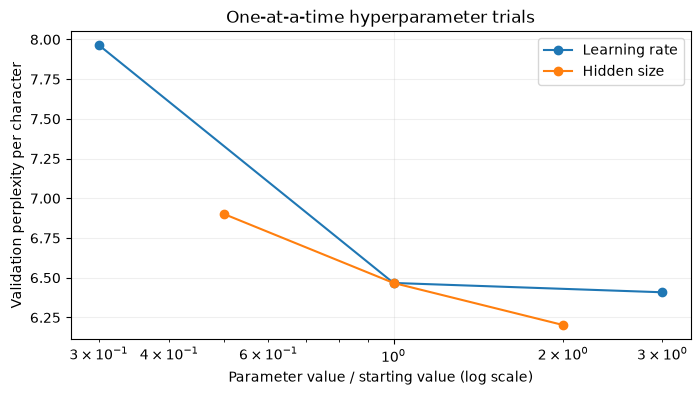

Over these tested ranges, **learning rate** matters more: its validation PP/character range is 1.5560, compared with 0.6992 for the other parameter. This conclusion is limited to these values and the fixed 2,000-step training budget.

Determinism check: both independent starting-configuration reruns match exactly.
FROZEN CHOICE (validation only): {'run': 'n_hidden_512', 'config': {'n': 3, 'k': 1000, 'n_embd': 64, 'n_hidden': 512, 'batch_size': 64, 'lr': 0.001, 'max_steps': 2000}, 'validation_pp_char': 6.202307365040522}
Test data has not been used to calculate loss or perplexity so far.


In [21]:
# Experiment 1: only k changes.
k_runs = {1000: baseline}
for k in (250, 4000):
    k_runs[k] = run_experiment(f'k_{k}', k=k)

# Experiment 3: exactly six separate training runs, all at the starting k.
hyper_rows = []
for parameter, values in [('lr', [3e-4, 1e-3, 3e-3]), ('n_hidden', [128, 256, 512])]:
    for value in values:
        result = run_experiment(f'{parameter}_{value}', **{parameter: value})
        hyper_rows.append({'parameter': parameter, 'value': value,
            'relative_to_start': value / BASE[parameter],
            'PP/token (validation)': result['val_pp'],
            'PP/character (validation)': result['val_pp_char'],
            'training seconds': result['train_seconds']})
hyper_table = pd.DataFrame(hyper_rows)
display(hyper_table)

fig, ax = plt.subplots(figsize=(8, 4))
for parameter, group in hyper_table.groupby('parameter', sort=False):
    ax.plot(group['relative_to_start'], group['PP/character (validation)'],
            marker='o', label='Learning rate' if parameter == 'lr' else 'Hidden size')
ax.set_xscale('log')
ax.set(xlabel='Parameter value / starting value (log scale)',
       ylabel='Validation perplexity per character', title='One-at-a-time hyperparameter trials')
ax.legend()
ax.grid(alpha=0.2)
plt.show()
spreads = hyper_table.groupby('parameter')['PP/character (validation)'].agg(lambda s: s.max() - s.min())
more_sensitive = {'lr': 'learning rate', 'n_hidden': 'hidden size'}[spreads.idxmax()]
display(Markdown(f"Over these tested ranges, **{more_sensitive}** matters more: its validation PP/character range is {spreads.max():.4f}, compared with {spreads.min():.4f} for the other parameter. This conclusion is limited to these values and the fixed 2,000-step training budget."))

# Same seeds, configuration, batch sequence, and arithmetic must reproduce a run.
for name in ['lr_0.001', 'n_hidden_256']:
    assert runs[name]['history'].equals(baseline['history'])
    assert all(torch.equal(value, runs[name]['model'].state_dict()[key])
               for key, value in baseline['model'].state_dict().items())
print('Determinism check: both independent starting-configuration reruns match exactly.')

best = min(runs.values(), key=lambda run: run['val_pp_char'])
best_data = data_by_k[best['config']['k']]
best_model, best_tok = best['model'], best_data['tok']
selection = dict(run=best['name'], config=best['config'], validation_pp_char=best['val_pp_char'])
Path('results').mkdir(exist_ok=True)
Path('results/selection_before_test.json').write_text(json.dumps(selection, indent=2))
print('FROZEN CHOICE (validation only):', selection)
print('Test data has not been used to calculate loss or perplexity so far.')

In [22]:
# Final test phase: evaluate each requested model once and retain the results.
test_scores = {}
def test_once(run):
    name = run['name']
    if name not in test_scores:
        test_scores[name] = batched_perplexity(run['model'], data_by_k[run['config']['k']]['ids']['test'])
    return test_scores[name]

k_rows = []
for k in sorted(k_runs):
    result = k_runs[k]
    test_pp, test_char = test_once(result)
    k_rows.append({'k (merges)': k, 'V': len(data_by_k[k]['tok'].vocab),
        'validation PP/token': result['val_pp'], 'validation PP/character': result['val_pp_char'],
        'test PP/token': test_pp, 'test PP/character': test_char})
k_table = pd.DataFrame(k_rows)
display(k_table)
best_k_row = k_table.loc[k_table['validation PP/character'].idxmin()]
display(Markdown(
    f"With all other settings fixed, k={int(best_k_row['k (merges)'])} has the lowest validation perplexity per character ({best_k_row['validation PP/character']:.4f}) among the three tested values. "
    "The token and character measures can disagree because larger k changes the vocabulary and the number of predictions per character: predicting a longer token is a different task, whereas the character denominator stays fixed."
))

# Experiment 2: compare the chosen neural configuration and the matched count model.
count_model = NGramLM(n=N, vocab_size=len(best_tok.vocab))
started = time.perf_counter()
count_model.fit(best_data['ids']['train'])
count_seconds = time.perf_counter() - started
count_shakespeare = perplexity(count_model, best_data['ids']['test'])
neural_shakespeare = test_once(best)
comparison = pd.DataFrame([
    {'model': 'Count trigram (Laplace)', 'n': N, 'k': best['config']['k'],
     'test PP/token': count_shakespeare[0], 'test PP/character': count_shakespeare[1],
     'parameters or stored counts': count_model.stored_counts, 'training seconds': count_seconds},
    {'model': 'Neural trigram', 'n': N, 'k': best['config']['k'],
     'test PP/token': neural_shakespeare[0], 'test PP/character': neural_shakespeare[1],
     'parameters or stored counts': best['parameters'], 'training seconds': best['train_seconds']},
])
display(comparison)
winner = 'neural model' if neural_shakespeare[1] < count_shakespeare[1] else 'count model'
display(Markdown(
    f"The {winner} wins on Shakespeare test perplexity per character ({neural_shakespeare[1]:.4f} neural versus {count_shakespeare[1]:.4f} count). "
    f"The neural model costs {best['train_seconds']:.2f} seconds to train and stores {best['parameters']:,} scalar parameters, compared with {count_seconds:.2f} seconds and {count_model.stored_counts:,} count entries for the count model; dictionary overhead and BPE training are excluded."
))
k_table.to_csv('results/k_experiment.csv', index=False)
hyper_table.to_csv('results/hyperparameters.csv', index=False)
comparison.to_csv('results/shakespeare_comparison.csv', index=False)

,k (merges),V,validation PP/token,validation PP/character,test PP/token,test PP/character
0,250,293,17.692573,6.870852,20.618878,7.769272
1,1000,1043,30.292047,6.467211,36.898537,7.599481
2,4000,4043,56.266740,6.509941,72.328172,7.981458


With all other settings fixed, k=1000 has the lowest validation perplexity per character (6.4672) among the three tested values. The token and character measures can disagree because larger k changes the vocabulary and the number of predictions per character: predicting a longer token is a different task, whereas the character denominator stays fixed.

,model,n,k,test PP/token,test PP/character,parameters or stored counts,training seconds
0,Count trigram (Laplace),3,1000,109.067946,13.974878,111761,0.173938
1,Neural trigram,3,1000,34.629830,7.333202,667859,3.021013


The neural model wins on Shakespeare test perplexity per character (7.3332 neural versus 13.9749 count). The neural model costs 3.02 seconds to train and stores 667,859 scalar parameters, compared with 0.17 seconds and 111,761 count entries for the count model; dictionary overhead and BPE training are excluded.

### Task 5

Generation and a second domain.

The best model is already frozen. The original repository contained no three prompts, so use these documented provisional prompts: `shall i compare thee`, `to be or not to be`, and `first citizen`. Generate ten samples total, cycling through all three prompts, plus one argmax output per prompt (three total). All use the same model-independent `generate` function; seeds are displayed and a stopping reason is attached to each output.

Download only the specified PTB **test** file. Verify its line count and MD5, print the first two lines, replace literal `<unk>` with `unknown`, and pass it through the same clean normalization and the already-fitted Shakespeare tokenizer. Neither model trains on this text. Compare the ratio WSJ/Shakespeare within each model and measure: the corpora have different tokenization lengths, so use PP/character as the primary domain-degradation comparison.

In [23]:
PROMPTS = ['shall i compare thee', 'to be or not to be', 'first citizen']
for i in range(10):
    prompt = PROMPTS[i % len(PROMPTS)]
    print(f'\nSAMPLE {i + 1} | seed={SEED + i} | prompt={prompt!r}')
    print(generate(best_model, best_tok, prompt, mode='sample', max_tokens=50, seed=SEED + i))
for i, prompt in enumerate(PROMPTS):
    print(f'\nARGMAX {i + 1} | prompt={prompt!r}')
    print(generate(best_model, best_tok, prompt, mode='argmax', max_tokens=50, seed=SEED))


SAMPLE 1 | seed=42 | prompt='shall i compare thee'
shall i compare thee by no young friendro; prostane, [stopped: <eos>]

SAMPLE 2 | seed=43 | prompt='to be or not to be'
to be or not to be feted statd for many seen [stopped: <eos>]

SAMPLE 3 | seed=44 | prompt='first citizen'
first citizen my knesent in himself, [stopped: <eos>]

SAMPLE 4 | seed=45 | prompt='shall i compare thee'
shall i compare thee which break up with now had quiy, made kryly [stopped: <eos>]

SAMPLE 5 | seed=46 | prompt='to be or not to be'
to be or not to be rrise the though them siwell, where the ney, aoued said [stopped: <eos>]

SAMPLE 6 | seed=47 | prompt='first citizen'
first citizen again, [stopped: <eos>]

SAMPLE 7 | seed=48 | prompt='shall i compare thee'
shall i compare thee i'll printhery: [stopped: <eos>]

SAMPLE 8 | seed=49 | prompt='to be or not to be'
to be or not to be de? [stopped: <eos>]

SAMPLE 9 | seed=50 | prompt='first citizen'
first citizen any down like with a worthe [stopped: <eos>]

SAMPLE

In [24]:
ptb_path = download_if_missing('data/ptb.test.txt', PTB_URL)
ptb_bytes = ptb_path.read_bytes()
ptb_raw = ptb_bytes.decode('utf-8')
print('PTB line count:', len(ptb_raw.splitlines()))
print('PTB MD5:', hashlib.md5(ptb_bytes).hexdigest())
print('First two raw lines:')
print('\n'.join(ptb_raw.splitlines()[:2]))
assert len(ptb_raw.splitlines()) == 3761
assert hashlib.md5(ptb_bytes).hexdigest() == PTB_MD5
print('Literal <unk> occurrences replaced:', ptb_raw.count('<unk>'))
wsj_lines = [normalize(line) for line in ptb_raw.replace('<unk>', 'unknown').splitlines()]
wsj_ids = encode_lines(best_tok, wsj_lines, n=N)
print('Tokenizer <unk> IDs after normalization/encoding:', sum(seq.count(best_tok.unk_id) for seq in wsj_ids))
count_wsj = perplexity(count_model, wsj_ids)
neural_wsj = batched_perplexity(best_model, wsj_ids)
domain_table = pd.DataFrame([
    {'model': 'Count trigram (Laplace)', 'Shakespeare PP/token': count_shakespeare[0],
     'Shakespeare PP/character': count_shakespeare[1], 'WSJ PP/token': count_wsj[0],
     'WSJ PP/character': count_wsj[1]},
    {'model': 'Neural trigram', 'Shakespeare PP/token': neural_shakespeare[0],
     'Shakespeare PP/character': neural_shakespeare[1], 'WSJ PP/token': neural_wsj[0],
     'WSJ PP/character': neural_wsj[1]},
])
domain_table['WSJ/Shakespeare PP/token'] = domain_table['WSJ PP/token'] / domain_table['Shakespeare PP/token']
domain_table['WSJ/Shakespeare PP/character'] = domain_table['WSJ PP/character'] / domain_table['Shakespeare PP/character']
display(domain_table)
count_ratio, neural_ratio = count_wsj[1] / count_shakespeare[1], neural_wsj[1] / neural_shakespeare[1]
faster = 'neural model' if neural_ratio > count_ratio else 'count model'
if count_ratio > 1 and neural_ratio > 1:
    reason = 'Both models get worse per character because financial news uses different vocabulary and context patterns from the Shakespeare training data.'
else:
    reason = 'Domain shift changes vocabulary, contexts, and tokenization lengths; these measurements do not show an increase in PP/character for both models, so the expected degradation should not be asserted for both.'
display(Markdown(reason + f' The {faster} has the larger WSJ/Shakespeare PP/character ratio ({neural_ratio:.3f} neural versus {count_ratio:.3f} count), measuring the relative domain change rather than just comparing raw scores.'))
domain_table.to_csv('results/domain_comparison.csv', index=False)

TOTAL_SECONDS = time.perf_counter() - NOTEBOOK_START
runtime = dict(seconds=TOTAL_SECONDS, device=device, seed=SEED,
               machine=platform.platform(), architecture=platform.machine(),
               torch=torch.__version__, threads=torch.get_num_threads(),
               maximum_training_seconds=max(run['train_seconds'] for run in runs.values()))
Path('results/runtime.json').write_text(json.dumps(runtime, indent=2))
print(f'\nTotal notebook execution: {TOTAL_SECONDS:.2f} seconds ({TOTAL_SECONDS / 60:.2f} minutes).')
print(f"Longest neural run: {runtime['maximum_training_seconds']:.2f} seconds.")
print('All experiment choices were frozen before the test-evaluation phase.')

PTB line count: 3761
PTB MD5: 8b80168b89c18661a38ef683c0dc3721
First two raw lines:
 no it was n't black monday 
 but while the new york stock exchange did n't fall apart friday as the dow jones industrial average plunged N points most of it in the final hour it barely managed to stay this side of chaos 
Literal <unk> occurrences replaced: 4794
Tokenizer <unk> IDs after normalization/encoding: 22


,model,Shakespeare PP/token,Shakespeare PP/character,WSJ PP/token,WSJ PP/character,WSJ/Shakespeare PP/token,WSJ/Shakespeare PP/character
0,Count trigram (Laplace),109.067946,13.974878,187.849600,20.437829,1.722317,1.462469
1,Neural trigram,34.629830,7.333202,58.863899,10.471129,1.699803,1.427907


Both models get worse per character because financial news uses different vocabulary and context patterns from the Shakespeare training data. The count model has the larger WSJ/Shakespeare PP/character ratio (1.428 neural versus 1.462 count), measuring the relative domain change rather than just comparing raw scores.


Total notebook execution: 31.65 seconds (0.53 minutes).
Longest neural run: 6.41 seconds.
All experiment choices were frozen before the test-evaluation phase.


# 4: GPT from scratch

### Task 1

### Task 2

### Task 3

### Task 4

### Task 5